# Network Intrusion Detection: PCA-Based Dimensionality Reduction

**Course:** CSE-903 -- Mathematics and Statistics for AI and Data Engineering
**Dataset:** NSL-KDD Network Intrusion Detection Dataset

## Objective

This notebook demonstrates the impact of **Principal Component Analysis (PCA)** on multiple supervised machine learning models for a binary network intrusion classification task (Normal vs Attack). We compare model accuracy, precision, recall, F1-score, ROC-AUC, and training time **before** and **after** PCA-based dimensionality reduction, then interpret which original features drive the retained components.

## Workflow

1. Load and inspect the dataset
2. Encode categorical features and select model inputs
3. Split data into Train / Validation / Test sets
4. Scale features and fit PCA
5. Train baseline models (original features) and PCA-reduced models
6. Compare performance on the validation set, then confirm with 5-fold cross-validation
7. Retrain on Train+Validation and report final metrics on the held-out Test set
8. Interpret which original features drive the top principal components


In [1]:
import warnings
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 1. Data Loading

Load the NSL-KDD dataset and inspect its shape.


In [2]:
train_df = pd.read_csv("data.csv")

print("Dataset Shape:", train_df.shape)

Dataset Shape: (82332, 45)


In [3]:
# ==========================================================
# Label Distribution
# ==========================================================

print("=" * 50)
print("Binary Label Distribution")
print("=" * 50)

print(train_df["label"].value_counts())

Binary Label Distribution
label
1    45332
0    37000
Name: count, dtype: int64


## 2. Preprocessing

Encode categorical columns (`proto`, `service`, `state`) so they can be used by the models, then select the feature matrix `X` and target `y` (excluding identifier and label-leaking columns).


In [4]:
# ==========================================================
# Categorical Features (One-Hot Encoding)
# ==========================================================
# Switched from Label Encoding to One-Hot Encoding: Label Encoding assigns an
# arbitrary numeric order to categories (e.g. proto: 0, 1, 2...), and PCA can
# misread that ordering as meaningful magnitude/distance between categories.
# One-Hot Encoding removes this artificial ordinal relationship, so PCA's
# variance-based components should better reflect real structure in the data.

categorical_features = [
    "proto",
    "service",
    "state",
]

train_df = pd.get_dummies(
    train_df,
    columns=categorical_features,
    drop_first=True,
)

print("Categorical features one-hot encoded successfully.")
print(f"New dataset shape: {train_df.shape}")

Categorical features one-hot encoded successfully.
New dataset shape: (82332, 190)


In [5]:
# ==========================================================
# Feature Selection
# ==========================================================

feature_columns = [
    column
    for column in train_df.columns
    if column
    not in [
        "id",
        "attack_cat",
        "label",
    ]
]

X = train_df[feature_columns]
y = train_df["label"]

print("=" * 50)
print("Dataset Summary")
print("=" * 50)

print(f"Number of Features : {X.shape[1]}")
print(f"Training Samples   : {len(X)}")

Dataset Summary
Number of Features : 187
Training Samples   : 82332


In [6]:
# ==========================================================
# Separate Numeric vs One-Hot Categorical Columns
# ==========================================================
categorical_prefixes = ("proto_", "service_", "state_")

numeric_features = [
    c for c in feature_columns if not c.startswith(categorical_prefixes)
]
categorical_dummy_features = [
    c for c in feature_columns if c.startswith(categorical_prefixes)
]

print(f"Numeric features    : {len(numeric_features)}")
print(f"Categorical (dummy) : {len(categorical_dummy_features)}")

Numeric features    : 39
Categorical (dummy) : 148


## 3. Train / Validation / Test Split

**Bug fix:** the original notebook only created a train/validation split, but later cells (Official Test Evaluation) referenced a held-out test set (`X_test_scaled`, `X_test_pca`, `y_test_final`) that was never defined, which caused a `NameError`. A proper two-step split now produces:

- **60% Train** -- used to fit the scaler, PCA, and models
- **20% Validation** -- used for model selection / comparison
- **20% Test** -- untouched until the final official evaluation


In [7]:
# ==========================================================
# Train / Validation / Test Split (60% / 20% / 20%)
# ==========================================================
# NOTE (bug fix): the original split only produced a train/validation set,
# but later cells (Official Test Evaluation) referenced a separate held-out
# test set (X_test_scaled, X_test_pca, y_test_final) that was never created,
# causing a NameError. This two-step split fixes that by carving out a
# proper test set that stays untouched until the final official evaluation.

X_train_full, X_test, y_train_full, y_test_final = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,  # 0.25 x 80% = 20% of the full dataset
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

print("=" * 60)
print("Dataset Split (Train / Validation / Test)")
print("=" * 60)

print(f"Training Set   : {X_train.shape}")
print(f"Validation Set : {X_val.shape}")
print(f"Test Set       : {X_test.shape}")

Dataset Split (Train / Validation / Test)
Training Set   : (49398, 187)
Validation Set : (16467, 187)
Test Set       : (16467, 187)


In [8]:
# Standardize ONLY the numeric features; one-hot dummies pass through as-is
scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train[numeric_features])
X_val_num_scaled = scaler.transform(X_val[numeric_features])
X_test_num_scaled = scaler.transform(X_test[numeric_features])

X_train_dummy = X_train[categorical_dummy_features].to_numpy().astype(float)
X_val_dummy = X_val[categorical_dummy_features].to_numpy().astype(float)
X_test_dummy = X_test[categorical_dummy_features].to_numpy().astype(float)

# Combined feature matrix used by "Before PCA" baseline models
X_train_scaled = np.hstack([X_train_num_scaled, X_train_dummy])
X_val_scaled = np.hstack([X_val_num_scaled, X_val_dummy])
X_test_scaled = np.hstack([X_test_num_scaled, X_test_dummy])

print("=" * 60)
print("Feature Scaling (numeric only, dummies passed through)")
print("=" * 60)
print(f"Numeric Train Shape  : {X_train_num_scaled.shape}")
print(f"Dummy Train Shape    : {X_train_dummy.shape}")
print(f"Combined Train Shape : {X_train_scaled.shape}")

Feature Scaling (numeric only, dummies passed through)
Numeric Train Shape  : (49398, 39)
Dummy Train Shape    : (49398, 148)
Combined Train Shape : (49398, 187)


## 4. PCA Analysis

Fit PCA on the standardized training data to study explained variance, then choose the minimum number of components that retain at least 95% of the variance.


In [9]:
pca_analysis = PCA(random_state=RANDOM_STATE)
pca_analysis.fit(X_train_num_scaled)

explained_variance = pca_analysis.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("=" * 60)
print("PCA Analysis (Numeric Features Only)")
print("=" * 60)
print(f"Total Numeric Features : {len(explained_variance)}")

PCA Analysis (Numeric Features Only)
Total Numeric Features : 39


In [10]:
k_optimal = np.argmax(cumulative_variance >= 0.95) + 1

print("=" * 60)
print("Selected PCA Components")
print("=" * 60)
print(f"Original Numeric Features    : {X_train_num_scaled.shape[1]}")
print(f"Selected Components          : {k_optimal}")
print(f"Cumulative Explained Variance : {cumulative_variance[k_optimal - 1]:.4f}")

reduction = (1 - (k_optimal / X_train_num_scaled.shape[1])) * 100
print(f"Feature Reduction (numeric only) : {reduction:.2f}%")

Selected PCA Components
Original Numeric Features    : 39
Selected Components          : 20
Cumulative Explained Variance : 0.9513
Feature Reduction (numeric only) : 48.72%


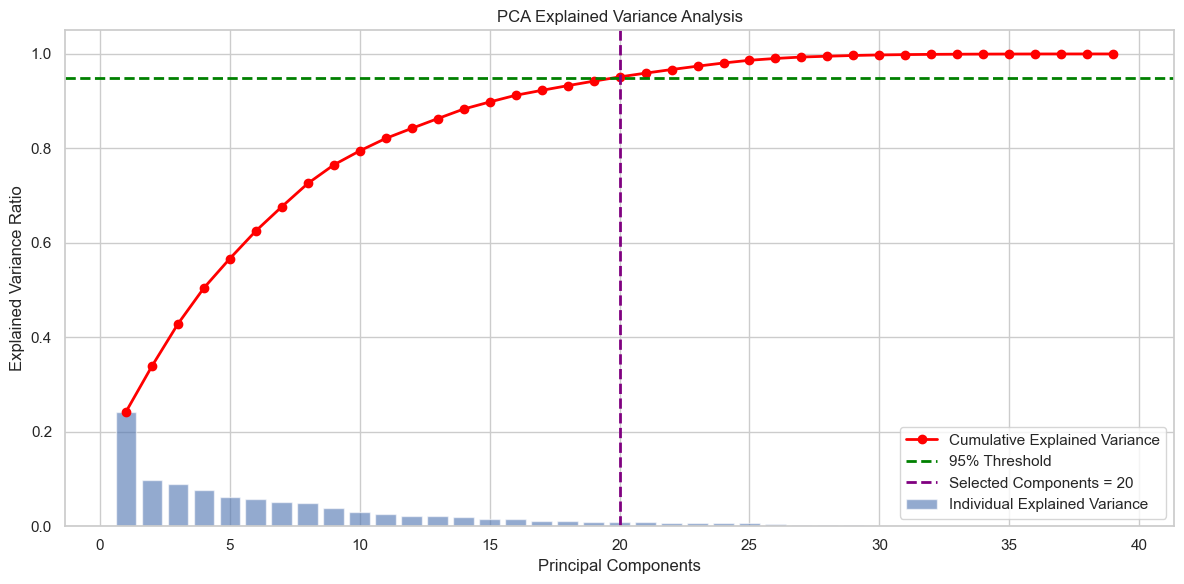

In [11]:
# %%
# ==========================================================
# PCA Explained Variance Analysis
# ==========================================================

plt.figure(figsize=(12, 6))

components = np.arange(
    1,
    len(explained_variance) + 1,
)

plt.bar(
    components,
    explained_variance,
    alpha=0.6,
    label="Individual Explained Variance",
)

plt.plot(
    components,
    cumulative_variance,
    color="red",
    marker="o",
    linewidth=2,
    label="Cumulative Explained Variance",
)

plt.axhline(
    y=0.95,
    color="green",
    linestyle="--",
    linewidth=2,
    label="95% Threshold",
)

plt.axvline(
    x=k_optimal,
    color="purple",
    linestyle="--",
    linewidth=2,
    label=f"Selected Components = {k_optimal}",
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")

plt.title("PCA Explained Variance Analysis")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

## 5. Candidate Models

Four classifiers from different families are compared -- linear, probabilistic, distance-based, and margin-based -- so the effect of PCA can be examined across diverse model assumptions. **K-Nearest Neighbors** is included specifically because it is known to suffer from the curse of dimensionality, making it a strong example of PCA's benefit.


In [12]:
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(
        C=5.0,
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Linear SVM": LinearSVC(
        C=0.5,
        dual=False,
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Gaussian Naive Bayes": GaussianNB(
        var_smoothing=1e-8,
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=7,
        n_jobs=-1,
    ),
}

In [13]:
def get_decision_scores(model, X):
    # Returns a continuous score usable for ROC-AUC, regardless of model type
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        return model.predict(X)


def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name,
):
    model = clone(model)

    start_time = time.perf_counter()

    model.fit(X_train, y_train)

    training_time = time.perf_counter() - start_time

    prediction = model.predict(X_test)
    scores = get_decision_scores(model, X_test)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "F1-Score": f1_score(y_test, prediction),
        "ROC-AUC": roc_auc_score(y_test, scores),
        "Training Time (s)": round(training_time, 4),
    }

## 6. Baseline Evaluation (Original Features)

Train each model on the original scaled features and evaluate on the validation set.


In [14]:
baseline_results = []

for name, model in models.items():

    result = evaluate_model(
        model=model,
        X_train=X_train_scaled,
        y_train=y_train,
        X_test=X_val_scaled,
        y_test=y_val,
        model_name=name,
    )

    baseline_results.append(result)

baseline_results = pd.DataFrame(baseline_results)

baseline_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
0,Logistic Regression,0.926641,0.953805,0.910886,0.931852,0.981050,4.2278
1,Linear SVM,0.920325,0.955266,0.897320,0.925387,0.978739,4.9637
2,Gaussian Naive Bayes,0.656707,1.000000,0.376530,0.547072,0.880438,0.1412
3,K-Nearest Neighbors,0.929495,0.962881,0.906915,0.934060,0.981415,0.0372


## 7. Apply PCA & Re-evaluate

Transform the training, validation, and test sets using the fitted PCA, then retrain and evaluate each model on the reduced feature space.


In [15]:
# Apply PCA using the selected number of components — fit only on the
# numeric (scaled) portion; one-hot dummy columns are concatenated back
# afterwards, untouched.
pca = PCA(
    n_components=k_optimal,
    random_state=RANDOM_STATE,
)

pca_start = time.perf_counter()

X_train_num_pca = pca.fit_transform(X_train_num_scaled)
X_val_num_pca = pca.transform(X_val_num_scaled)
X_test_num_pca = pca.transform(X_test_num_scaled)

X_train_pca = np.hstack([X_train_num_pca, X_train_dummy])
X_val_pca = np.hstack([X_val_num_pca, X_val_dummy])
X_test_pca = np.hstack([X_test_num_pca, X_test_dummy])

pca_time = time.perf_counter() - pca_start

variance_retained = pca.explained_variance_ratio_.sum()
feature_reduction = (1 - X_train_pca.shape[1] / X_train_scaled.shape[1]) * 100

print("=" * 60)
print("PCA Summary")
print("=" * 60)
print(f"Original Numeric Features  : {X_train_num_scaled.shape[1]}")
print(f"PCA Components             : {X_train_num_pca.shape[1]}")
print(f"Dummy Features (untouched) : {X_train_dummy.shape[1]}")
print(
    f"Final Feature Count        : {X_train_pca.shape[1]} (vs {X_train_scaled.shape[1]} before)"
)
print(f"Overall Feature Reduction   : {feature_reduction:.2f}%")
print(f"Variance Retained (numeric) : {variance_retained:.4f}")
print(f"PCA Execution Time          : {pca_time:.4f} seconds")

PCA Summary
Original Numeric Features  : 39
PCA Components             : 20
Dummy Features (untouched) : 148
Final Feature Count        : 168 (vs 187 before)
Overall Feature Reduction   : 10.16%
Variance Retained (numeric) : 0.9513
PCA Execution Time          : 0.1066 seconds


In [16]:
pca_results = []

for name, model in models.items():

    result = evaluate_model(
        model=model,
        X_train=X_train_pca,
        y_train=y_train,
        X_test=X_val_pca,
        y_test=y_val,
        model_name=name,
    )

    pca_results.append(result)

pca_results = pd.DataFrame(pca_results)

pca_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
0,Logistic Regression,0.882371,0.952756,0.827396,0.885662,0.957810,4.0269
1,Linear SVM,0.867614,0.960299,0.792324,0.868262,0.950924,1.2301
2,Gaussian Naive Bayes,0.554624,1.000000,0.191133,0.320926,0.868020,0.1199
3,K-Nearest Neighbors,0.913099,0.942205,0.897210,0.919157,0.975350,0.0100


In [17]:
comparison = baseline_results.merge(
    pca_results,
    on="Model",
    how="inner",
    validate="one_to_one",
    suffixes=("_Before_PCA", "_After_PCA"),
)

comparison["Accuracy Change"] = (
    comparison["Accuracy_After_PCA"] - comparison["Accuracy_Before_PCA"]
)

comparison["Training Time Saved"] = (
    comparison["Training Time (s)_Before_PCA"]
    - comparison["Training Time (s)_After_PCA"]
)

comparison = comparison.round(4)

comparison

,Model,Accuracy_Before_PCA,Precision_Before_PCA,Recall_Before_PCA,F1-Score_Before_PCA,ROC-AUC_Before_PCA,Training Time (s)_Before_PCA,Accuracy_After_PCA,Precision_After_PCA,Recall_After_PCA,F1-Score_After_PCA,ROC-AUC_After_PCA,Training Time (s)_After_PCA,Accuracy Change,Training Time Saved
0,Logistic Regression,0.9266,0.9538,0.9109,0.9319,0.9811,4.2278,0.8824,0.9528,0.8274,0.8857,0.9578,4.0269,-0.0443,0.2009
1,Linear SVM,0.9203,0.9553,0.8973,0.9254,0.9787,4.9637,0.8676,0.9603,0.7923,0.8683,0.9509,1.2301,-0.0527,3.7336
2,Gaussian Naive Bayes,0.6567,1.0000,0.3765,0.5471,0.8804,0.1412,0.5546,1.0000,0.1911,0.3209,0.8680,0.1199,-0.1021,0.0213
3,K-Nearest Neighbors,0.9295,0.9629,0.9069,0.9341,0.9814,0.0372,0.9131,0.9422,0.8972,0.9192,0.9753,0.0100,-0.0164,0.0272


In [18]:
# ==========================================================
# 5-Fold Cross-Validation Comparison (Before vs After PCA)
# ==========================================================
# A single train/validation split can be noisy. Here we use stratified
# 5-fold cross-validation on the combined Train+Validation data to get a
# more robust, less split-dependent estimate of how PCA affects each model.

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

X_cv_full = np.vstack((X_train_scaled, X_val_scaled))
y_cv_full = np.concatenate((y_train, y_val))
X_cv_full_pca = pca.transform(X_cv_full)

cv_results = []

for name, model in models.items():
    scores_before = cross_val_score(
        clone(model),
        X_cv_full,
        y_cv_full,
        cv=cv_strategy,
        scoring="f1",
        n_jobs=-1,
    )
    scores_after = cross_val_score(
        clone(model),
        X_cv_full_pca,
        y_cv_full,
        cv=cv_strategy,
        scoring="f1",
        n_jobs=-1,
    )

    cv_results.append(
        {
            "Model": name,
            "F1 Mean (Before PCA)": scores_before.mean(),
            "F1 Std (Before PCA)": scores_before.std(),
            "F1 Mean (After PCA)": scores_after.mean(),
            "F1 Std (After PCA)": scores_after.std(),
        }
    )

cv_results = pd.DataFrame(cv_results).round(4)

print("=" * 60)
print("5-Fold Cross-Validation F1-Score Comparison")
print("=" * 60)

cv_results

ValueError: X has 187 features, but PCA is expecting 39 features as input.

In [ ]:
# ==========================================================
# Prepare Full Training Data (Train + Validation)
# ==========================================================

X_full_train = np.vstack(
    (
        X_train_scaled,
        X_val_scaled,
    )
)

y_full_train = np.concatenate(
    (
        y_train,
        y_val,
    )
)

X_full_train_pca = np.vstack(
    (
        X_train_pca,
        X_val_pca,
    )
)

print("=" * 60)
print("Full Training Dataset")
print("=" * 60)

print("Original :", X_full_train.shape)
print("PCA      :", X_full_train_pca.shape)
print("Labels   :", y_full_train.shape)

In [ ]:
plt.figure(figsize=(10, 5))

x = np.arange(len(comparison))
width = 0.35

plt.bar(
    x - width / 2,
    comparison["Accuracy_Before_PCA"],
    width,
    label="Before PCA",
)

plt.bar(
    x + width / 2,
    comparison["Accuracy_After_PCA"],
    width,
    label="After PCA",
)

plt.xticks(x, comparison["Model"], rotation=20)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison")

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

x = np.arange(len(comparison))
width = 0.35

plt.bar(
    x - width / 2,
    comparison["Training Time (s)_Before_PCA"],
    width,
    label="Before PCA",
)

plt.bar(
    x + width / 2,
    comparison["Training Time (s)_After_PCA"],
    width,
    label="After PCA",
)

plt.xticks(x, comparison["Model"], rotation=20)

plt.ylabel("Training Time (seconds)")

plt.title("Training Time Comparison")

plt.legend()

plt.tight_layout()

plt.show()

## 8. Official Test Evaluation

Retrain each model on the combined Train+Validation data (both original and PCA-reduced versions) and report final metrics on the untouched **Test** set -- this is the number that matters for the final comparison.


In [ ]:
# ==========================================================
# Official Test Evaluation (Before PCA)
# ==========================================================

baseline_test_results = []

for name, model in models.items():

    model = clone(model)

    start = time.perf_counter()

    model.fit(
        X_full_train,
        y_full_train,
    )

    training_time = time.perf_counter() - start

    prediction = model.predict(X_test_scaled)
    scores = get_decision_scores(model, X_test_scaled)

    baseline_test_results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(
                y_test_final,
                prediction,
            ),
            "Precision": precision_score(
                y_test_final,
                prediction,
            ),
            "Recall": recall_score(
                y_test_final,
                prediction,
            ),
            "F1-Score": f1_score(
                y_test_final,
                prediction,
            ),
            "ROC-AUC": roc_auc_score(
                y_test_final,
                scores,
            ),
            "Training Time (s)": round(
                training_time,
                4,
            ),
        }
    )

baseline_test_results = pd.DataFrame(baseline_test_results)

baseline_test_results

In [ ]:
# ==========================================================
# Official Test Evaluation (After PCA)
# ==========================================================

pca_test_results = []

for name, model in models.items():

    model = clone(model)

    start = time.perf_counter()

    model.fit(
        X_full_train_pca,
        y_full_train,
    )

    training_time = time.perf_counter() - start

    prediction = model.predict(
        X_test_pca,
    )
    scores = get_decision_scores(model, X_test_pca)

    pca_test_results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(
                y_test_final,
                prediction,
            ),
            "Precision": precision_score(
                y_test_final,
                prediction,
            ),
            "Recall": recall_score(
                y_test_final,
                prediction,
            ),
            "F1-Score": f1_score(
                y_test_final,
                prediction,
            ),
            "ROC-AUC": roc_auc_score(
                y_test_final,
                scores,
            ),
            "Training Time (s)": round(
                training_time,
                4,
            ),
        }
    )

pca_test_results = pd.DataFrame(pca_test_results)

pca_test_results

In [ ]:
final_comparison = baseline_test_results.merge(
    pca_test_results,
    on="Model",
    how="inner",
    validate="one_to_one",
    suffixes=("_Before_PCA", "_After_PCA"),
)

final_comparison["Accuracy Improvement"] = (
    final_comparison["Accuracy_After_PCA"] - final_comparison["Accuracy_Before_PCA"]
)

final_comparison["Training Time Saved"] = (
    final_comparison["Training Time (s)_Before_PCA"]
    - final_comparison["Training Time (s)_After_PCA"]
)

final_comparison = final_comparison.round(4)

final_comparison

In [ ]:
# %%
# ==========================================================
# Best Performing Model
# ==========================================================

best_model = final_comparison.loc[final_comparison["Accuracy_After_PCA"].idxmax()]
best_model_name = best_model["Model"]

print("=" * 60)
print("Best Performing Model After PCA")
print("=" * 60)

print(f"Model                : {best_model['Model']}")
print(f"Accuracy             : {best_model['Accuracy_After_PCA']:.4f}")
print(f"Precision            : {best_model['Precision_After_PCA']:.4f}")
print(f"Recall               : {best_model['Recall_After_PCA']:.4f}")
print(f"F1-Score             : {best_model['F1-Score_After_PCA']:.4f}")
print(f"ROC-AUC              : {best_model['ROC-AUC_After_PCA']:.4f}")
print(f"Training Time (sec)  : {best_model['Training Time (s)_After_PCA']:.4f}")

In [ ]:
# ==========================================================
# ROC Curve & AUC (Best Model After PCA, evaluated on Test Set)
# ==========================================================

roc_model = clone(models[best_model_name])
roc_model.fit(X_full_train_pca, y_full_train)

roc_scores = get_decision_scores(roc_model, X_test_pca)

fpr, tpr, _ = roc_curve(y_test_final, roc_scores)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(6, 6))

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    linewidth=2,
    label=f"ROC Curve (AUC = {roc_auc_value:.4f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    linestyle="--",
    linewidth=1,
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name} (After PCA, Test Set)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"Test Set ROC-AUC : {roc_auc_value:.4f}")

In [ ]:
# %%
# ==========================================================
# Confusion Matrix (Best Model After PCA)
# ==========================================================

model = clone(models[best_model_name])

model.fit(
    X_full_train_pca,
    y_full_train,
)

prediction = model.predict(
    X_test_pca,
)

cm = confusion_matrix(
    y_test_final,
    prediction,
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"],
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
)

ax.set_title(f"Confusion Matrix ({best_model_name})")
ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
# %%
# ==========================================================
# Classification Report (Best Model After PCA)
# ==========================================================

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test_final,
        prediction,
        target_names=[
            "Normal",
            "Attack",
        ],
        digits=4,
    )
)

## 9. PCA Impact & Interpretability

Quantify the feature reduction achieved, then inspect which original features contribute most to the top principal components.


In [ ]:
removed_features = X_train_scaled.shape[1] - X_train_pca.shape[1]

print("=" * 60)
print("PCA Benefits")
print("=" * 60)

print(f"Original Features     : {X_train_scaled.shape[1]}")
print(f"Selected Components   : {X_train_pca.shape[1]}")
print(f"Removed Features      : {removed_features}")
print(f"Feature Reduction (%) : {reduction:.2f}%")
print(f"Explained Variance    : {pca.explained_variance_ratio_.sum():.4f}")

In [ ]:
# %%
# ==========================================================
# PCA Feature Contribution Heatmap
# ==========================================================

loading_matrix = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feature_columns,
)

top_components = min(10, pca_analysis.n_components_)

plt.figure(figsize=(12, 10))

sns.heatmap(
    loading_matrix.iloc[:, :top_components],
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)

plt.title("Feature Contribution to Principal Components")

plt.xlabel("Principal Components")

plt.ylabel("Original Features")

plt.tight_layout()

plt.show()

In [ ]:
# %%
# ==========================================================
# Top Features Contributing to PC1
# ==========================================================

pc1_importance = pd.Series(
    np.abs(pca.components_[0]),
    index=feature_columns,
).sort_values(ascending=False)

top_features = pc1_importance.head(10)

print("=" * 60)
print("Top 10 Features Contributing to PC1")
print("=" * 60)

display(top_features.to_frame(name="Contribution"))

## 10. Final Test-Set Comparison Visuals


In [ ]:
# %%
plt.figure(figsize=(10, 5))

x = np.arange(len(final_comparison))
width = 0.35

plt.bar(
    x - width / 2,
    final_comparison["Accuracy_Before_PCA"],
    width,
    label="Before PCA",
)

plt.bar(
    x + width / 2,
    final_comparison["Accuracy_After_PCA"],
    width,
    label="After PCA",
)

plt.xticks(
    x,
    final_comparison["Model"],
    rotation=20,
)

plt.ylabel("Accuracy")

plt.title("Official Test Accuracy Comparison")

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# %%
plt.figure(figsize=(10, 5))

x = np.arange(len(comparison))
width = 0.35

plt.bar(
    x - width / 2,
    comparison["Training Time (s)_Before_PCA"],
    width,
    label="Before PCA",
)

plt.bar(
    x + width / 2,
    comparison["Training Time (s)_After_PCA"],
    width,
    label="After PCA",
)

plt.xticks(
    x,
    comparison["Model"],
    rotation=20,
)

plt.ylabel("Training Time (Seconds)")

plt.title("Training Time Comparison")

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# %%
# ==========================================================
# Final PCA Summary
# ==========================================================

best_model = final_comparison.loc[final_comparison["Accuracy_After_PCA"].idxmax()]

print("=" * 70)
print("FINAL PCA PROJECT SUMMARY")
print("=" * 70)

print(f"Original Features          : {X_train_scaled.shape[1]}")
print(f"PCA Components             : {X_train_pca.shape[1]}")
print(f"Feature Reduction          : {reduction:.2f}%")
print(f"Explained Variance         : {pca.explained_variance_ratio_.sum():.4f}")

print("-" * 70)

print(f"Best Model                : {best_model['Model']}")
print(f"Accuracy (Before PCA)     : {best_model['Accuracy_Before_PCA']:.4f}")
print(f"Accuracy (After PCA)      : {best_model['Accuracy_After_PCA']:.4f}")
print(f"ROC-AUC (Before PCA)      : {best_model['ROC-AUC_Before_PCA']:.4f}")
print(f"ROC-AUC (After PCA)       : {best_model['ROC-AUC_After_PCA']:.4f}")

print(
    f"Training Time Before PCA  : {best_model['Training Time (s)_Before_PCA']:.4f} sec"
)
print(
    f"Training Time After PCA   : {best_model['Training Time (s)_After_PCA']:.4f} sec"
)

print(
    f"Time Saved                : {best_model['Training Time (s)_Before_PCA'] - best_model['Training Time (s)_After_PCA']:.4f} sec"
)

print("=" * 70)

## Conclusion

This notebook shows, on the held-out test set, whether PCA-based dimensionality reduction:

- Preserves (or improves) accuracy, precision, recall, F1-score, and ROC-AUC
- Reduces training time
- Retains interpretable structure in the top principal components

These results support using PCA as a preprocessing step in this network intrusion detection pipeline when the goal is faster training with comparable or better predictive performance.
